In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_excel('last_test.xlsx')
df = df.rename(columns={"Unnamed: 0": "url"})
df.head()

,url,brand,model,year,power,price,city,odometer,engine_volume,fuel_type,transmission,color,steering_wheel,owners_count
0,https://auto.drom.ru/spb/kia/rio/146872596.html,kia,rio,2015,123.0,850000,Санкт-Петербург,205 000,1.6,бензин,автомат,коричневый,левый,1.0
1,https://auto.drom.ru/odintsovo/ford/focus/1860...,ford,focus,2011,125.0,740000,Одинцово,199700,1.6,бензин,механика,черный,левый,3.0
2,https://auto.drom.ru/rostov-na-donu/ford/focus...,ford,focus,2013,105.0,500000,Ростов-на-Дону,315000,1.6,бензин,автомат,белый,левый,3.0
3,https://auto.drom.ru/istra/ford/focus/37890279...,ford,focus,2019,125.0,1280000,Истра,59300,1.6,бензин,автомат,серебристый,левый,1.0
4,https://auto.drom.ru/rostov-na-donu/volkswagen...,volkswagen,polo,2014,85.0,745000,Ростов-на-Дону,168000,1.6,бензин,автомат,белый,левый,2.0


#Обработка данных

In [8]:
numeric_cols = ["year", "power", "price", "odometer", "engine_volume", "owners_count"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["odometer"].between(5000, 500000)]
df = df.dropna()

In [9]:
mo_cities = [
    "люберцы", "домодедово", "подольск", "пушкино", "балашиха", "мытищи",
    "коломна", "электросталь", "королёв", "королев", "красногорск",
    "видное", "жуковский", "щёлково", "щелково", "чехов", "химки",
    "ступино", "лобня", "серпухов", "одинцово", "истра", "сергиев",
    "сергиев посад", "зеленоград", "орехово-зуево", "наро-фоминск",
    "раменское", "дубна", "ногинск", "ивантеевка", "тучково", "клин",
    "воскресенск", "дмитров", "шатура", "долгопрудный", "котельники",
    "можайск", "егорьевск", "хотьково", "бронницы", "михнево",
    "железнодорожный", "володарского", "голицыно", "лосино-петровский",
    "павловский", "волоколамск", "апрелевка", "пущино", "электрогорск",
    "любучаны", "краснознаменск", "звенигород", "обухово", "троицк",
    "кашира", "электроугли", "власиха", "быково", "верея", "андреевка",
    "дзержинский", "куровское", "дорохово", "кубинка", "фрязино",
    "снегири", "речицы", "развилка"]

df["city"] = df["city"].str.lower().str.strip()
df["region"] = df["city"]
df.loc[df["city"].isin(mo_cities), "region"] = "московская область"
df.loc[df["city"] == "нижний", "region"] = "нижний новгород"
df["region"] = df["region"].str.title()
df = df[~df["region"].isin(["Лмс", "Старый", "Старая"])]

df["region"].value_counts()

,count
region,
Новосибирск,402
Москва,246
Московская Область,215
Тюмень,214
Екатеринбург,189
Санкт-Петербург,149
Краснодар,144
Челябинск,131
Владивосток,92


In [10]:
df["fuel_type"].value_counts()

,count
fuel_type,
бензин,2014
дизель,10
гибрид,1
электро,1


In [11]:
df = df.drop(columns=["fuel_type"])
df = df.drop(columns=["city"])

In [12]:
df["color"] = df["color"].astype(str).str.lower().str.strip()

df["color"] = df["color"].replace("чёрный", "черный")
df["color"].value_counts()

,count
color,
белый,626
черный,328
серый,326
серебристый,248
синий,163
красный,88
коричневый,80
бежевый,50
голубой,47


In [13]:
def group_color(color):
    color = str(color).strip().lower()

    if color in ["белый"]:
        return "white"
    elif color in ["черный"]:
        return "black"
    elif color in ["серый", "серебристый"]:
        return "gray_silver"
    else:
        return "other_color"

df["color_group"] = df["color"].apply(group_color)

df["color_group"].value_counts()

,count
color_group,
white,626
gray_silver,574
other_color,498
black,328


In [14]:
def make_region(region):
    if region in ["Москва", "Московская Область"]:
        return "moscow"
    else:
        return "other"

df["region_group"] = df["region"].apply(make_region)

<Figure size 1000x1000 with 0 Axes>

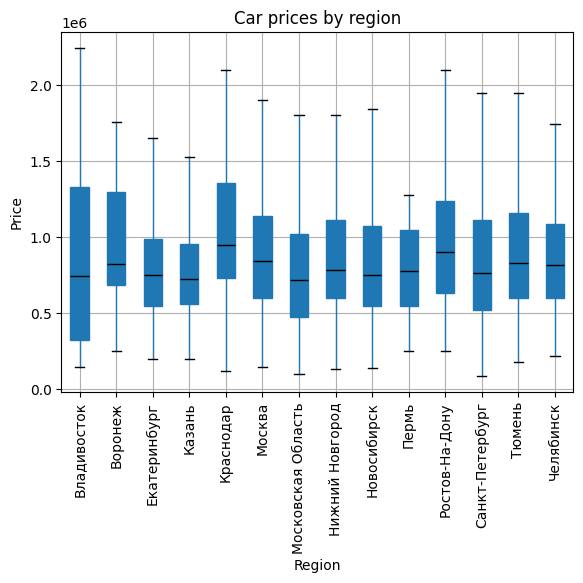

In [45]:
plt.figure(figsize=(10, 10))
df.boxplot(column="price", by="region", patch_artist=True, showfliers=False, medianprops={"color": "black", "linewidth": 1})
plt.xlabel("Region")
plt.ylabel("Price")
plt.title("Car prices by region")
plt.suptitle("")
plt.xticks(rotation=90)
plt.show()

In [16]:
df["automatic_dummy"] = df["transmission"].isin(["автомат", "вариатор", "робот"]).astype(int)
df["right_wheel_dummy"] = (df["steering_wheel"] == "правый").astype(int)
df["age"] = 2026 - df["year"]

df["ln_price"] = np.log(df["price"])
df["ln_odometer"] = np.log(df["odometer"])

df["brand"] = df["brand"].astype(str).str.strip()
df["model"] = df["model"].astype(str).str.strip()

df["brand_model"] = df["brand"] + "_" + df["model"]

cat_cols = ["brand_model", "region_group", "color_group"]

df = pd.get_dummies(df, columns=["brand_model"], drop_first=False)
df = pd.get_dummies(df, columns=["color_group"], drop_first=False)
df = pd.get_dummies(df, columns=["region_group"], drop_first=False)


df = df.drop(columns=['brand_model_lada_vesta'])
df = df.drop(columns=["color_group_black"])
df = df.drop(columns=["region_group_other"])

df_new = df.copy()
df_new = df_new.drop(columns=["price", "odometer", "url", "brand", "model", "year", "region", "transmission", "color", "steering_wheel"])
df_new

,power,engine_volume,owners_count,automatic_dummy,right_wheel_dummy,age,ln_price,ln_odometer,brand_model_ford_focus,brand_model_hyundai_solaris,brand_model_kia_rio,brand_model_renault_logan,brand_model_skoda_rapid,brand_model_toyota_corolla,brand_model_volkswagen_polo,color_group_gray_silver,color_group_other_color,color_group_white,region_group_moscow
1,125.0,1.6,3.0,0,0,15,13.514405,12.204572,True,False,False,False,False,False,False,False,False,False,True
2,105.0,1.6,3.0,1,0,13,13.122363,12.660328,True,False,False,False,False,False,False,False,False,True,False
3,125.0,1.6,1.0,1,0,7,14.062371,10.990365,True,False,False,False,False,False,False,True,False,False,True
4,85.0,1.6,2.0,1,0,12,13.521139,12.031719,False,False,False,False,False,False,True,False,False,True,False
5,123.0,1.6,3.0,0,0,13,13.429848,12.388394,False,False,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2088,89.0,1.5,2.0,1,1,26,12.611538,12.429216,False,False,False,False,False,True,False,False,False,True,False
2089,110.0,1.6,2.0,1,0,10,13.764217,11.904968,False,False,False,False,False,False,True,False,False,True,False
2090,80.0,1.3,2.0,1,1,31,12.072541,12.498063,False,False,False,False,False,True,False,False,False,True,False
2091,100.0,1.3,4.0,1,1,33,12.154779,12.614866,False,False,False,False,False,True,False,False,True,False,False


In [17]:
df_new.describe().round(2)

,power,engine_volume,owners_count,automatic_dummy,right_wheel_dummy,age,ln_price,ln_odometer
count,2026.00,2026.00,2026.00,2026.00,2026.00,2026.00,2026.00,2026.00
mean,112.29,1.59,2.59,0.65,0.08,13.08,13.54,12.01
std,16.02,0.15,1.07,0.48,0.27,6.12,0.53,0.62
min,55.00,1.00,1.00,0.00,0.00,1.00,11.41,8.52
25%,105.00,1.60,2.00,0.00,0.00,8.00,13.22,11.71
50%,110.00,1.60,3.00,1.00,0.00,13.00,13.58,12.13
75%,123.00,1.60,4.00,1.00,0.00,16.00,13.91,12.43
max,250.00,2.50,4.00,1.00,1.00,38.00,14.91,13.12


#Графики

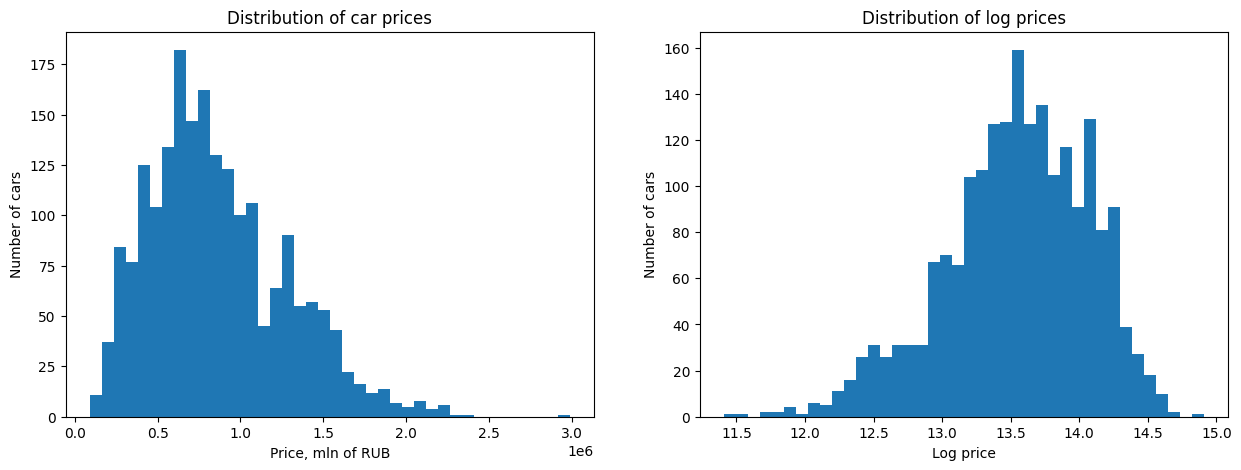

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(df["price"], bins=40)
axes[0].set_xlabel("Price, mln of RUB")
axes[0].set_ylabel("Number of cars")
axes[0].set_title("Distribution of car prices")

axes[1].hist(df["ln_price"], bins=40)
axes[1].set_xlabel("Log price")
axes[1].set_ylabel("Number of cars")
axes[1].set_title("Distribution of log prices")
plt.show()

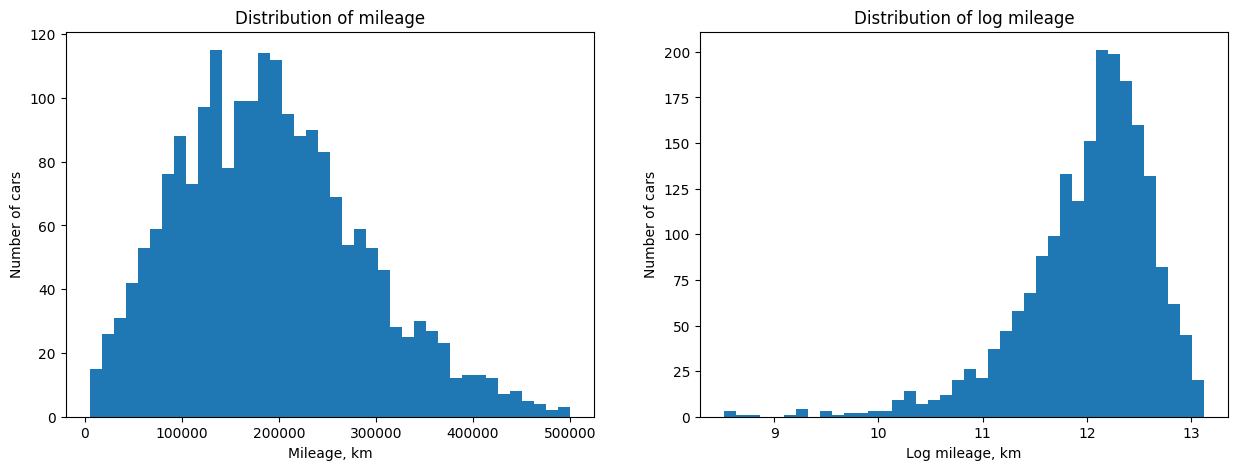

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df["odometer"], bins=40)
axes[0].set_xlabel("Mileage, km")
axes[0].set_ylabel("Number of cars")
axes[0].set_title("Distribution of mileage")

axes[1].hist(df["ln_odometer"], bins=40)
axes[1].set_xlabel("Log mileage, km")
axes[1].set_ylabel("Number of cars")
axes[1].set_title("Distribution of log mileage")
plt.show()

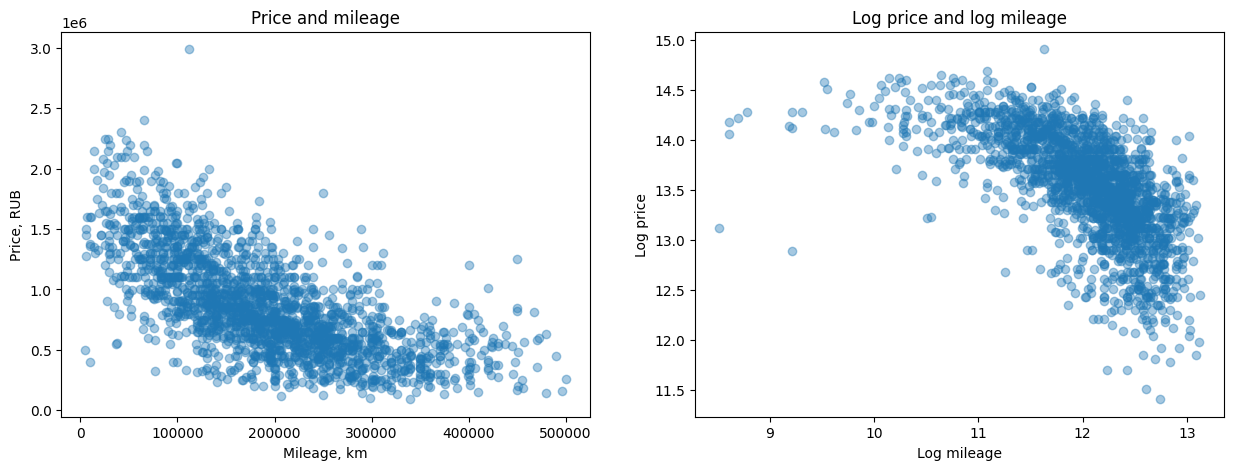

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(df["odometer"], df["price"], alpha=0.4)
axes[0].set_xlabel("Mileage, km")
axes[0].set_ylabel("Price, RUB")
axes[0].set_title("Price and mileage")

axes[1].scatter(df["ln_odometer"], df["ln_price"], alpha=0.4)
axes[1].set_xlabel("Log mileage")
axes[1].set_ylabel("Log price")
axes[1].set_title("Log price and log mileage")

plt.show()

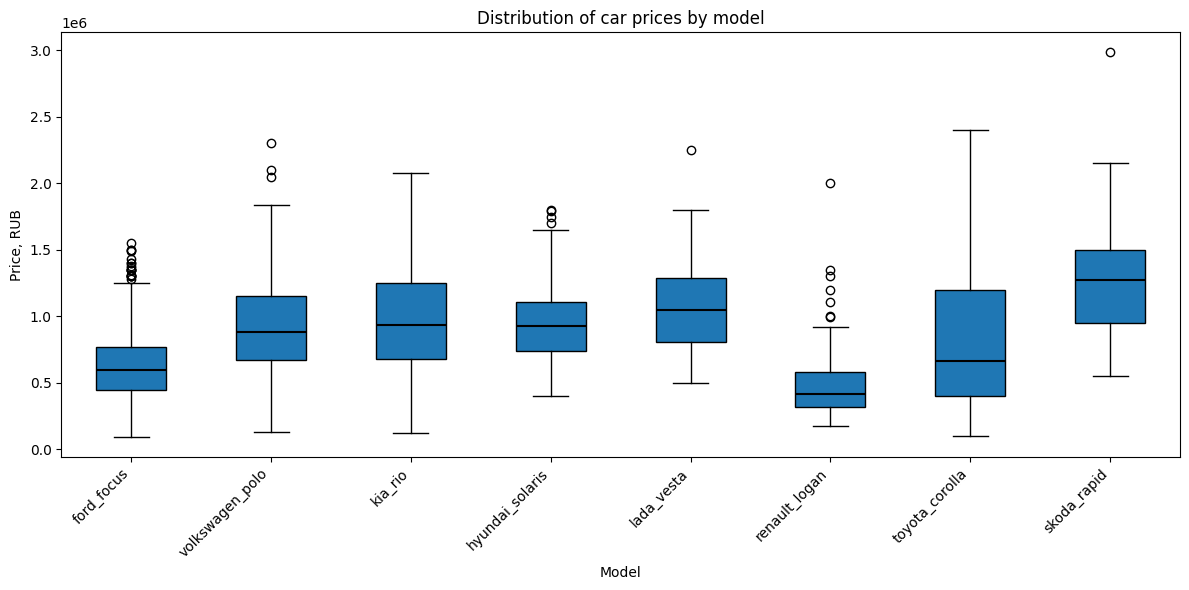

In [21]:
df["brand_model"] = df["brand"] + "_" + df["model"]
models = df["brand_model"].dropna().unique()

data = [
    df.loc[df["brand_model"] == model, "price"]
    for model in models
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    data,
    tick_labels=models,
    patch_artist=True,
    showfliers=True,
    medianprops={"color": "black", "linewidth": 1.5}
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Model")
plt.ylabel("Price, RUB")
plt.title("Distribution of car prices by model")
plt.tight_layout()
plt.show()

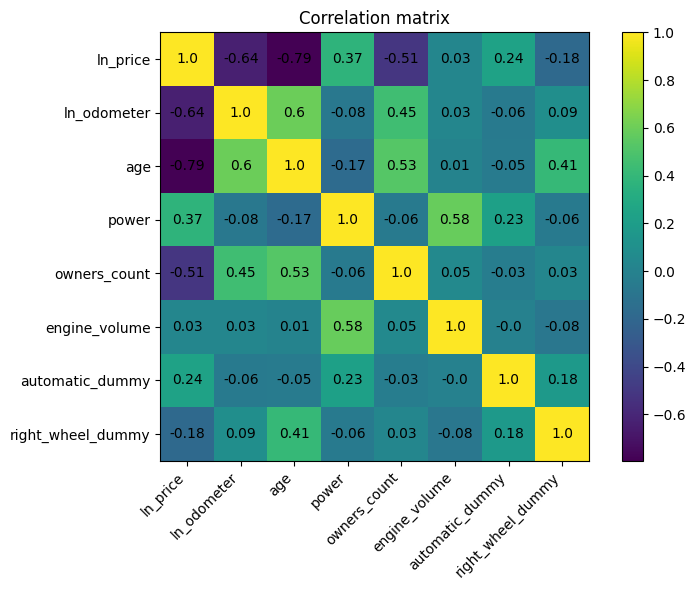

In [22]:
num_cols = [
    "ln_price",
    "ln_odometer",
    "age",
    "power",
    "owners_count",
    "engine_volume",
    "automatic_dummy",
    "right_wheel_dummy"
]

corr = df_new[num_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha="center", va="center")

plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

#OLS

In [23]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [24]:
X = df_new.drop(columns=["ln_price"])
X = sm.add_constant(X)
y = df_new["ln_price"]

In [25]:
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

## Базовый OLS

In [26]:
ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     578.0
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        18:59:56   Log-Likelihood:                 269.91
No. Observations:                2026   AIC:                            -501.8
Df Residuals:                    2007   BIC:                            -395.2
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.copy()

vif_data = pd.DataFrame()
vif_data["variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data["variable"] != "const"]
vif_data = vif_data.sort_values("VIF", ascending=False)
vif_data

,variable,VIF
13,brand_model_toyota_corolla,5.010831
8,brand_model_ford_focus,4.759487
9,brand_model_hyundai_solaris,3.468089
6,age,3.412786
10,brand_model_kia_rio,3.364703
1,power,2.900648
14,brand_model_volkswagen_polo,2.736854
2,engine_volume,2.220004
17,color_group_white,2.186966
15,color_group_gray_silver,2.001784


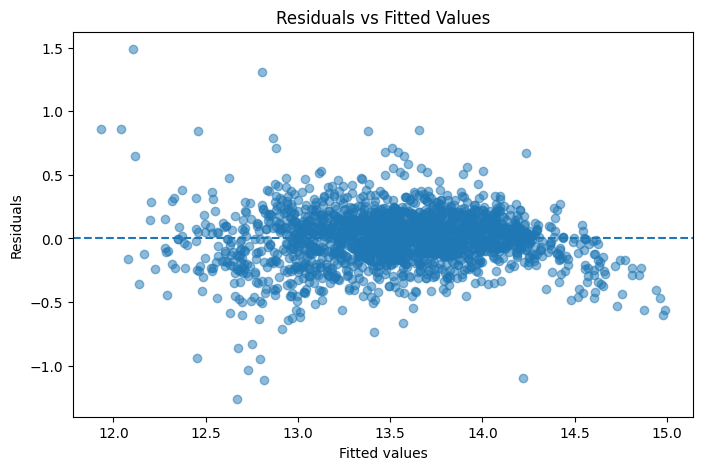

In [28]:
import matplotlib.pyplot as plt

fitted = ols_model.fittedvalues
residuals = ols_model.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

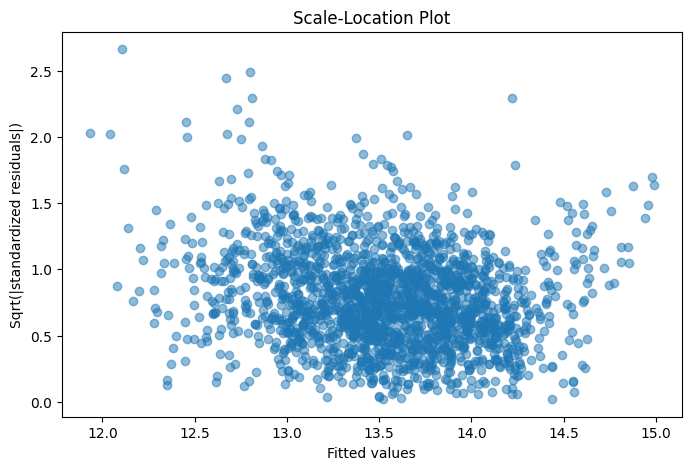

In [29]:
standardized_resid = ols_model.get_influence().resid_studentized_internal

plt.figure(figsize=(8, 5))
plt.scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha=0.5)
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|standardized residuals|)")
plt.title("Scale-Location Plot")
plt.show()

##Робастные ошибки

In [30]:
ols_robust = sm.OLS(y, X).fit(cov_type="HC1")

print(ols_robust.summary())

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     398.1
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        18:59:57   Log-Likelihood:                 269.91
No. Observations:                2026   AIC:                            -501.8
Df Residuals:                    2007   BIC:                            -395.2
Df Model:                          18                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

#IV модель

In [31]:
trans_instr = pd.read_excel("transport_instrument.xlsx")
trans_instr.head()

,region,transport_index
0,Новосибирск,70.1
1,Москва,89.9
2,Московская Область,89.9
3,Тюмень,59.0
4,Екатеринбург,76.0


In [32]:
fuel_instr = pd.read_excel("fuel_instrument.xlsx")
fuel_instr.head()

,region,fuel_price
0,Новосибирск,66.20
1,Москва,70.25
2,Московская Область,68.84
3,Тюмень,67.98
4,Екатеринбург,67.10


In [33]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.6 MB/s eta 0:00:00


In [34]:
from linearmodels.iv import IV2SLS

df_instr = trans_instr.merge(fuel_instr, on="region")
df_iv = df.merge(df_instr, on="region", how="left")

y_iv = df_new["ln_price"]
endog = df_new["ln_odometer"]
instr = df_iv[["transport_index", "fuel_price"]]

In [35]:
df_instr[["transport_index", "fuel_price"]].corr()

,transport_index,fuel_price
transport_index,1.000000,-0.205868
fuel_price,-0.205868,1.000000


In [36]:
X_iv = X.drop(columns=["ln_odometer"])

iv_model = IV2SLS(dependent=y_iv,
    exog=X_iv,
    endog=endog,
    instruments=instr).fit(cov_type="robust")

print(iv_model.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:               ln_price   R-squared:                      0.6641
Estimator:                    IV-2SLS   Adj. R-squared:                 0.6611
No. Observations:                2026   F-statistic:                    3685.7
Date:                Sun, May 24 2026   P-value (F-stat)                0.0000
Time:                        19:00:11   Distribution:                 chi2(18)
Cov. Estimator:                robust                                         
                                                                              
                                      Parameter Estimates                                      
                             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------------
const                           20.966     1.9849     10.562     0.0000      17.

In [37]:
print(iv_model.first_stage)

      First Stage Estimation Results     
                              ln_odometer
-----------------------------------------
R-squared                          0.4373
Partial R-squared                  0.0060
Shea's R-squared                   0.0060
Partial F-statistic                12.631
P-value (Partial F-stat)           0.0018
Partial F-stat Distn              chi2(2)
============================= ===========
const                              10.092
                                 (19.839)
power                              0.0005
                                 (0.5053)
engine_volume                      0.1684
                                 (1.5707)
owners_count                       0.0834
                                 (7.0410)
automatic_dummy                   -0.0795
                                (-3.3146)
right_wheel_dummy                 -0.2629
                                (-5.1123)
age                                0.0588
                                 (

In [38]:
print(iv_model.sargan)

Sargan's test of overidentification
H0: The model is not overidentified.
Statistic: 1.3284
P-value: 0.2491
Distributed: chi2(1)


In [39]:
print(iv_model.wu_hausman())

Wu-Hausman test of exogeneity
H0: All endogenous variables are exogenous
Statistic: 15.9180
P-value: 0.0001
Distributed: F(1,2006)


##C одним инструментом

In [40]:
iv_model = IV2SLS(dependent=y_iv,
    exog=X_iv,
    endog=endog,
    instruments=instr["transport_index"]).fit(cov_type="robust")

print(iv_model.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:               ln_price   R-squared:                      0.6652
Estimator:                    IV-2SLS   Adj. R-squared:                 0.6622
No. Observations:                2026   F-statistic:                    3695.1
Date:                Sun, May 24 2026   P-value (F-stat)                0.0000
Time:                        19:00:11   Distribution:                 chi2(18)
Cov. Estimator:                robust                                         
                                                                              
                                      Parameter Estimates                                      
                             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------------
const                           20.951     1.9836     10.562     0.0000      17.

In [41]:
print(iv_model.first_stage)

      First Stage Estimation Results     
                              ln_odometer
-----------------------------------------
R-squared                          0.4373
Partial R-squared                  0.0060
Shea's R-squared                   0.0060
Partial F-statistic                12.518
P-value (Partial F-stat)           0.0004
Partial F-stat Distn              chi2(1)
============================= ===========
const                              10.104
                                 (58.276)
power                              0.0005
                                 (0.5056)
engine_volume                      0.1684
                                 (1.5705)
owners_count                       0.0834
                                 (7.0464)
automatic_dummy                   -0.0795
                                (-3.3315)
right_wheel_dummy                 -0.2628
                                (-5.1330)
age                                0.0588
                                 (

# Проверка гипотезы ln_odometer * age

In [42]:
df_new["ln_odometer_age"] = df_new["ln_odometer"] * df_new["age"]

X = df_new.drop(columns=["ln_price"])
X = sm.add_constant(X)

bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

model_new = sm.OLS(df_new["ln_price"], X).fit(cov_type="HC1")
print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     418.8
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        19:00:11   Log-Likelihood:                 302.93
No. Observations:                2026   AIC:                            -565.9
Df Residuals:                    2006   BIC:                            -453.6
Df Model:                          19                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [43]:
df_new["transport_index"] = df_iv["transport_index"].values
df_new["transport_index_age"] = df_new["transport_index"] * df_new["age"]
y_iv = df_new["ln_price"]

endog = df_new[["ln_odometer", "ln_odometer_age"]]

instr = df_new[["transport_index", "transport_index_age"]]

X_interact_iv = df_new.drop(columns=[
    "ln_price",
    "ln_odometer",
    "ln_odometer_age",
    "transport_index",
    "transport_index_age"
], errors="ignore")

X_interact_iv = sm.add_constant(X_interact_iv)

bool_cols = X_interact_iv.select_dtypes(include="bool").columns
X_interact_iv[bool_cols] = X_interact_iv[bool_cols].astype(int)

iv_interact = IV2SLS(
    dependent=y_iv,
    exog=X_interact_iv,
    endog=endog,
    instruments=instr
).fit(cov_type="robust")

print(iv_interact.summary)
print(iv_interact.first_stage)

                          IV-2SLS Estimation Summary                          
Dep. Variable:               ln_price   R-squared:                     -0.9423
Estimator:                    IV-2SLS   Adj. R-squared:                -0.9607
No. Observations:                2026   F-statistic:                    671.19
Date:                Sun, May 24 2026   P-value (F-stat)                0.0000
Time:                        19:00:11   Distribution:                 chi2(19)
Cov. Estimator:                robust                                         
                                                                              
                                      Parameter Estimates                                      
                             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------------
const                           3.9348     14.641     0.2687     0.7881     -24.